# Boundary Regularization on SmartVote 2023

The IXPLORE posterior update combines likelihood and prior:

$$p(\mathbf{x} \mid \text{answers}) \propto p(\text{answers} \mid \mathbf{x}) \cdot p(\mathbf{x})$$

We compare two regularizers:
- **Gaussian** (current default): $R(\mathbf{x}) = \tfrac{\|\mathbf{x}\|^2}{2\tau^2}$ — quadratic penalty, centrally peaked.
- **Log-barrier**: $R(\mathbf{x}) = -\alpha [\log(1 - x^2) + \log(1 - y^2)]$ — flat interior, diverges at the grid edge.

**Research question:** _Can a log-barrier prior eliminate border-clustering without sacrificing predictive accuracy?_

This notebook is organized in two parts:
- **Part 1 — Embedding progression.** Training trajectories across five iterations for both priors at a range of strengths. Shows whether each prior pulls embeddings inward or lets them drift outward.
- **Part 2 — Predictive accuracy for new users.** Hold-out fit MAE and impute MAE for voters with varying numbers of observed answers, under four priors plus a uniform baseline.

In [1]:
import sys
sys.path.insert(0, "../..")

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from ixplore import IXPLORE
from ixplore.prior import set_gaussian_prior, set_log_barrier_prior
from ixplore.optimization import posterior_means, posterior_maps
from ixplore.visualization import plot_embedding, plot_posterior, clean_axis, colormap
import warnings
warnings.filterwarnings('ignore')

import logging
logging.basicConfig(level=logging.WARNING)

# Load data
from src.data import load_dataset
ds = load_dataset("smartvote_2023")
reactions = ds.train_reactions
info = ds.train_info
party_colors = info['color'].values

results_dir = Path("../../results/ixplore_design")
results_dir.mkdir(parents=True, exist_ok=True)

print(f"Dataset: {reactions.shape[0]} candidates, {reactions.shape[1]} questions")

Dataset: 1029 candidates, 75 questions


## Prior Function Families

The two priors compared in this notebook, evaluated along the $x$-axis at $y=0$ (both priors are symmetric in $x$ and $y$, so a 1-D slice fully describes the shape). Curves are shown for the strength values used in the analyses below.

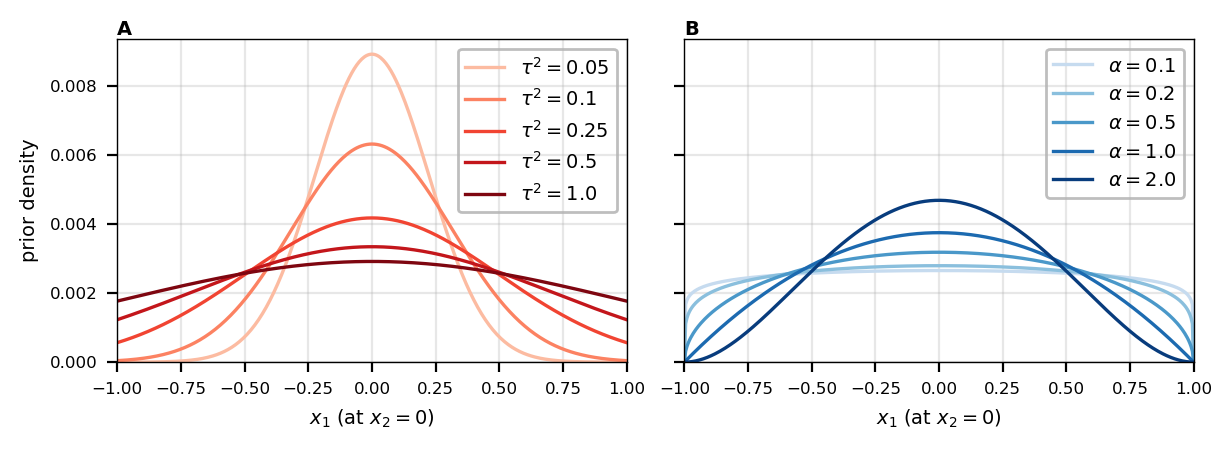

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from ixplore.prior import set_gaussian_prior, set_log_barrier_prior

from src.visualization import apply_defaults, subplots
apply_defaults()

gaussian_taus = [0.05, 0.1, 0.25, 0.5, 1.0]
log_barrier_alphas = [0.1, 0.2, 0.5, 1.0, 2.0]
LIMITS = (-1.0, 1.0)

xs = np.linspace(LIMITS[0], LIMITS[1], 401)
slice_grid = np.column_stack([xs, np.zeros_like(xs)])

fig, (ax_g, ax_lb) = subplots(1, 2, width_frac=1.0, aspect=0.35, sharey=True)

cmap_g = plt.get_cmap("Reds")
for i, tau in enumerate(gaussian_taus):
    p = set_gaussian_prior(slice_grid, prior_variance=tau, log=False)
    color = cmap_g(0.25 + 0.7 * i / max(len(gaussian_taus) - 1, 1))
    ax_g.plot(xs, p, color=color, label=fr"$\tau^2={tau}$")
ax_g.set_xlabel(r"$x_1$ (at $x_2=0$)")
ax_g.set_ylabel("prior density")
ax_g.set_xlim(LIMITS)
ax_g.set_ylim(bottom=0)
ax_g.legend(loc="upper right")

cmap_lb = plt.get_cmap("Blues")
for i, alpha in enumerate(log_barrier_alphas):
    p = set_log_barrier_prior(slice_grid, alpha=alpha, limits=LIMITS, log=False)
    color = cmap_lb(0.25 + 0.7 * i / max(len(log_barrier_alphas) - 1, 1))
    ax_lb.plot(xs, p, color=color, label=fr"$\alpha={alpha}$")
ax_lb.set_xlabel(r"$x_1$ (at $x_2=0$)")
ax_lb.set_xlim(LIMITS)
ax_lb.set_ylim(bottom=0)
ax_lb.legend(loc="upper right")

fig.text(-0, 1, "A", va="bottom", ha="left", weight="bold", transform=ax_g.transAxes)
fig.text(-0, 1, "B", va="bottom", ha="left", weight="bold", transform=ax_lb.transAxes)
fig.tight_layout(pad=0.2, rect=[0, 0, 1, 0.95], w_pad=0.7)
FIG_DIR = Path("../../figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)
fig.savefig(FIG_DIR / "prior_families_smartvote_2023.pdf")
plt.show()

In [3]:
def apply_gaussian(model, tau):
    """Swap a trained model's prior to Gaussian with variance tau."""
    model.log_prior = set_gaussian_prior(model.X, prior_variance=tau, log=True)

def apply_log_barrier(model, alpha):
    """Swap a trained model's prior to the log-barrier prior with strength alpha."""
    model.log_prior = set_log_barrier_prior(model.X, alpha=alpha,
                                              limits=model.limits, log=True)

## Section 1: Embedding Progression with Increasing Regularization

For each regularization method, we train a model with PCA initialization + 5 iterations at 5 different strengths, saving models at each iteration.

In [4]:
import copy

gaussian_taus = [0.05, 0.1, 0.25, 0.5, 1.0]
log_barrier_alphas = [0.1, 0.2, 0.5, 2.0, 5.0]
N_ITERATIONS = 5

def train_gaussian(tau):
    """Train with Gaussian prior, saving model state after each iteration."""
    model = IXPLORE(reactions, pca_initialization=True, random_state=0,
                    prior_variance=tau, scale_weights=False)
    models_by_iter = {}
    for i in range(1, N_ITERATIONS + 1):
        model.iterate(1)
        models_by_iter[i] = copy.deepcopy(model)
    return models_by_iter

def train_log_barrier(alpha):
    """Train with log-barrier prior, saving model state after each iteration."""
    model = IXPLORE(reactions, pca_initialization=True, random_state=0, scale_weights=False)
    apply_log_barrier(model, alpha)
    models_by_iter = {}
    for i in range(1, N_ITERATIONS + 1):
        model.iterate(1)
        apply_log_barrier(model, alpha)
        models_by_iter[i] = copy.deepcopy(model)
    return models_by_iter

print("Training Gaussian models...")
gaussian_models = {s: train_gaussian(s) for s in gaussian_taus}
print("Training log-barrier models...")
log_barrier_models = {a: train_log_barrier(a) for a in log_barrier_alphas}

# Collect per-iteration fit metrics for both regularizations
fit_rows = []
for tau, mdict in gaussian_models.items():
    for it, m in mdict.items():
        metrics = m.evaluate(boundary_threshold=0.10)
        fit_rows.append({'Prior': 'Gaussian', 'param': tau, 'iteration': it, **metrics})
for alpha, mdict in log_barrier_models.items():
    for it, m in mdict.items():
        metrics = m.evaluate(boundary_threshold=0.10)
        fit_rows.append({'Prior': 'Log-barrier', 'param': alpha, 'iteration': it, **metrics})

fit_metrics_df = pd.DataFrame(fit_rows)
fit_metrics_df.round(4).to_csv(results_dir / "boundary_regularization_fit_metrics.csv", index=False)
print(f"\nSaved {len(fit_metrics_df)} rows to boundary_regularization_fit_metrics.csv")

ixplore - INFO - 2026-09-11 18:23:08 - IXPLORE initialized: 1029 users × 75 items (0 missing, 0.00%), grid 200×200, prior var=0.05.


ixplore - INFO - 2026-09-11 18:23:08 - Initial — mae: 0.1845, accuracy: 0.8355, spread: 0.4572, boundary: 0.0661


Training Gaussian models...


ixplore - INFO - 2026-09-11 18:23:08 - Fit complete after 1 iterations — mae: 0.1825, accuracy: 0.8355, spread: 0.2345, boundary: 0.0000


ixplore - INFO - 2026-09-11 18:23:09 - Fit complete after 1 iterations — mae: 0.1816, accuracy: 0.8358, spread: 0.1657, boundary: 0.0000


...

ixplore - INFO - 2026-09-11 18:23:36 - Fit complete after 1 iterations — mae: 0.1819, accuracy: 0.8356, spread: 0.1945, boundary: 0.0000


ixplore - INFO - 2026-09-11 18:23:36 - Fit complete after 1 iterations — mae: 0.1813, accuracy: 0.8358, spread: 0.1608, boundary: 0.0000


ixplore - INFO - 2026-09-11 18:23:37 - Fit complete after 1 iterations — mae: 0.1810, accuracy: 0.8358, spread: 0.1395, boundary: 0.0000


ixplore - INFO - 2026-09-11 18:23:38 - Fit complete after 1 iterations — mae: 0.1808, accuracy: 0.8358, spread: 0.1249, boundary: 0.0000



Saved 50 rows to boundary_regularization_fit_metrics.csv


## Section 2: Train Fit + Embed New Users with Sparse Answers

We train a reference model on candidates (fixing item parameters), then embed new users (voters) with varying numbers of observed answers. For each regularization setting, we measure:
- **Fit MAE**: reconstruction error on observed answers
- **Impute MAE**: prediction error on held-out answers

Choose regularization values based on Section 1 results.

In [5]:
# Load voter data as test users
voters = ds.test_reactions
print(f"Test users: {voters.shape[0]} voters, {voters.shape[1]} questions.")

Test users: 1121 voters, 75 questions.


In [6]:
rng = np.random.default_rng(42)
n_items = len(reactions.columns)
n_observed_list = [5, 10, 15, 20, 30, 50, 75]

def make_eval_model(ref_model, reg_fn):
    """Clone item params from ref_model and apply the given prior."""
    item_params = ref_model.get_parameters()
    eval_model = IXPLORE(reactions, pretrained_models=item_params)
    reg_fn(eval_model)
    return eval_model

def uniform_prior(model):
    model.log_prior = np.zeros(model.X.shape[0])

reg_configs = [
    ('Gaussian $\\tau^2=1.0$',    lambda m: apply_gaussian(m, 1.0),     gaussian_models[1.0][N_ITERATIONS]),
    ('Gaussian $\\tau^2=0.1$',    lambda m: apply_gaussian(m, 0.1),     gaussian_models[0.1][N_ITERATIONS]),
    ('Log-barrier $\\alpha=0.5$', lambda m: apply_log_barrier(m, 0.5),  log_barrier_models[0.5][N_ITERATIONS]),
    ('Log-barrier $\\alpha=2.0$', lambda m: apply_log_barrier(m, 2.0),  log_barrier_models[2.0][N_ITERATIONS]),
    ('Uniform (no prior)',        uniform_prior,                         gaussian_models[1.0][N_ITERATIONS]),
]

results = []

for reg_name, reg_fn, ref_model in reg_configs:
    eval_model = make_eval_model(ref_model, reg_fn)
    print(f"Evaluating: {reg_name}")

    for n_obs in n_observed_list:
        fit_maes = []
        impute_maes = []

        for voter_idx in range(len(voters)):
            voter_series = voters.iloc[voter_idx]
            voter_values = voter_series.values

            observed_idx = rng.choice(n_items, size=min(n_obs, n_items), replace=False)
            held_out_idx = np.setdiff1d(np.arange(n_items), observed_idx)

            partial = pd.Series(np.nan, index=voter_series.index, dtype=float)
            partial.iloc[observed_idx] = voter_values[observed_idx]

            # Posterior-mean predictions for ALL items: fit MAE uses observed entries,
            # impute MAE uses held-out entries.
            preds = eval_model.predict_answers(partial).values

            fit_maes.append(np.abs(voter_values[observed_idx] - preds[observed_idx]).mean())
            if len(held_out_idx) > 0:
                impute_maes.append(np.abs(voter_values[held_out_idx] - preds[held_out_idx]).mean())

        results.append({
            'n_observed': n_obs,
            'regularization': reg_name,
            'fit_mae': np.mean(fit_maes),
            'impute_mae': np.mean(impute_maes) if impute_maes else np.nan,
        })
    print("  done")

results_df = pd.DataFrame(results)
results_df.round(4).to_csv(results_dir / "boundary_regularization_holdout.csv", index=False)
print(f"\n{len(results_df)} experiments saved to boundary_regularization_holdout.csv")

ixplore - INFO - 2026-09-11 18:23:38 - IXPLORE initialized: 1029 users × 75 items (0 missing, 0.00%), grid 200×200, prior var=1.0.


ixplore - INFO - 2026-09-11 18:23:38 - Initial — mae: 0.1792, accuracy: 0.8324, spread: 0.4572, boundary: 0.0661


Evaluating: Gaussian $\tau^2=1.0$


ixplore - INFO - 2026-09-11 18:23:50 - IXPLORE initialized: 1029 users × 75 items (0 missing, 0.00%), grid 200×200, prior var=1.0.


ixplore - INFO - 2026-09-11 18:23:50 - Initial — mae: 0.1802, accuracy: 0.8251, spread: 0.4572, boundary: 0.0661


...

  done
Evaluating: Log-barrier $\alpha=2.0$


ixplore - INFO - 2026-09-11 18:24:26 - IXPLORE initialized: 1029 users × 75 items (0 missing, 0.00%), grid 200×200, prior var=1.0.


ixplore - INFO - 2026-09-11 18:24:26 - Initial — mae: 0.1792, accuracy: 0.8324, spread: 0.4572, boundary: 0.0661


  done
Evaluating: Uniform (no prior)


  done

35 experiments saved to boundary_regularization_holdout.csv


In [7]:
results_df = pd.read_csv(results_dir / "boundary_regularization_holdout.csv")

pivot_fit = results_df.pivot(index='n_observed', columns='regularization', values='fit_mae')
pivot_impute = results_df.pivot(index='n_observed', columns='regularization', values='impute_mae')

print("Fit MAE (on observed answers):")
print(pivot_fit.to_string(float_format=lambda x: f"{x:.4f}"))
print("\nImpute MAE (on held-out answers):")
print(pivot_impute.to_string(float_format=lambda x: f"{x:.4f}"))

Fit MAE (on observed answers):
regularization  Gaussian $\tau^2=0.1$  Gaussian $\tau^2=1.0$  Log-barrier $\alpha=0.5$  Log-barrier $\alpha=2.0$  Uniform (no prior)
n_observed                                                                                                                          
5                              0.2023                 0.1915                    0.1960                    0.2005              0.1920
10                             0.2204                 0.2158                    0.2168                    0.2188              0.2135
15                             0.2289                 0.2220                    0.2253                    0.2255              0.2249
20                             0.2328                 0.2322                    0.2297                    0.2309              0.2294
30                             0.2386                 0.2337                    0.2350                    0.2381              0.2346
50                             0.2432 